# 🌾 Seasonal Agriculture Performance Analysis
## VOIS AICTE Batch 1 — Major Project (2026–2027)

**Project Type:** Data Analytics Major Project  
**Dataset:** `seasonal_agriculture_performance_dataset.csv`

### Project Theme
This notebook studies how agricultural performance changes across **Kharif, Rabi and Zaid seasons** using environmental, farming, resource-use, production and economic variables.

### Source brief
The project brief defines the task as identifying **seasonal patterns, trends, relationships, variations and unusual observations** in agricultural performance. It also requires suitable cleaning, statistical analysis, visualizations, evidence-based conclusions and recommendations.

> **Important:** This notebook is intentionally analytical rather than predictive-first. Any advanced model included later is used only to explore relationships and feature importance; it should not be interpreted as proof of causation.

# 1. Project Background

## Introduction to the Dataset
The dataset represents agricultural activities performed across different:
- seasons,
- geographical areas,
- crops,
- farming conditions,
- environmental conditions,
- resource-use patterns, and
- economic outcomes.

The dataset contains **4,000 farm-level records and 28 columns**. It provides a strong basis for comparing seasonal agricultural performance.

## Problem Statement
Agricultural activities are influenced by seasonal differences in environmental conditions, farming practices, resource availability and market conditions. Raw data alone does not clearly explain how performance differs between seasons.

Therefore, this project analyzes the dataset to identify:
- seasonal differences in agricultural performance,
- important trends and patterns,
- relationships between environmental/resource conditions and outcomes,
- regional and crop-level variation,
- unusual or unexpected patterns.

## Why This Problem Matters
Seasonal agricultural analysis can support:
- understanding performance variation,
- identifying seasonal trends,
- comparing different periods,
- understanding environmental differences,
- examining resource usage,
- identifying areas that need further investigation,
- evidence-based agricultural planning.

# 2. Project Objectives

The primary objective is to analyze agricultural data across seasons and identify meaningful **patterns, trends, relationships and differences** in performance.

### Specific objectives
1. Explore and understand the dataset.
2. Clean and prepare the data.
3. Compare agricultural performance across seasons.
4. Identify seasonal environmental patterns.
5. Examine resource-use variation.
6. Investigate relationships between conditions and agricultural outcomes.
7. Compare crops, regions and irrigation methods within seasons.
8. Identify statistically significant differences.
9. Detect unusual patterns and potential outliers.
10. Develop evidence-based conclusions and recommendations.
11. Document the complete analysis in a reproducible Jupyter/Google Colab notebook.

# 3. Key Analytical Questions

This notebook converts the project brief into the following specific questions:

1. How do **yield, production, revenue and profit** vary across Kharif, Rabi and Zaid?
2. What seasonal patterns appear in **rainfall, temperature, humidity, sunlight and soil moisture**?
3. Does **resource usage** such as fertilizer, pesticide and water differ across seasons?
4. How do **economic outcomes** vary across seasons?
5. Which **crops** perform best within each season?
6. Which **irrigation methods** are associated with stronger yield, profit and water efficiency?
7. Are seasonal patterns consistent across **states**?
8. What relationships exist between environmental conditions and **yield/profit**?
9. Are the seasonal differences statistically significant?
10. What unusual or unexpected patterns are present?
11. What evidence-based recommendations can support better seasonal planning?

# 4. Setup and Library Imports

The notebook uses:
- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib** for visualization
- **SciPy** for statistical testing
- **Scikit-learn** for an optional advanced relationship/feature-importance analysis

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, mannwhitneyu, spearmanr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 5. Load the Dataset in Google Colab

The cell below first checks whether the dataset is already present in `/content/`.  
If not, Colab will ask you to upload the CSV file.

**Required filename:** `seasonal_agriculture_performance_dataset.csv`

In [ ]:
DATASET_NAME = "seasonal_agriculture_performance_dataset.csv"
DATASET_PATH = f"/content/seasonal_agriculture_performance_dataset.csv"

if not os.path.exists(DATASET_PATH):
    try:
        from google.colab import files
        print(f"Please upload: {DATASET_NAME}")
        uploaded = files.upload()

        if DATASET_NAME in uploaded:
            DATASET_PATH = DATASET_NAME
        else:
            csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
            if not csv_files:
                raise FileNotFoundError("No CSV file was uploaded.")
            DATASET_PATH = csv_files[0]

    except ImportError:
        # Useful when running outside Google Colab
        DATASET_PATH = DATASET_NAME

df_raw = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
display(df_raw.head())

Dataset loaded successfully.
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
# Top 5 Rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Revenue_per_Ha,Cost_per_Ha,Profit_per_Ha,Water_Used_per_Ha,Is_Profitable
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"58,132.08","80,494.34","-22,362.26",447.17,0
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","6,186.98","75,398.32","-69,211.33",758.50,0
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"39,190.53","64,858.02","-25,667.49",262.35,0
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"44,608.89","65,876.44","-21,267.56",852.00,0
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"45,987.41","80,275.30","-34,287.89",780.76,0


In [ ]:
# Bottom 5 Rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Revenue_per_Ha,Cost_per_Ha,Profit_per_Ha,Water_Used_per_Ha,Is_Profitable
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20,-562.89,"11,599.15","76,889.19","-65,290.04",427.12,0
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70,80.67,"292,792.59","56,610.15","236,182.44",610.15,1
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20,-81.05,"41,444.22","75,036.49","-33,592.26",323.97,0
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40,12.63,"101,826.59","88,961.85","12,864.74",705.20,1
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30,-17.26,"67,982.48","79,719.64","-11,737.16",543.81,0


# 6. Initial Dataset Understanding

In [ ]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:02d}. {col}")

print("\nData types:")
display(df_raw.dtypes.to_frame("Data Type"))

print("\nSample records:")
display(df_raw.sample(5, random_state=42))

Rows: 4000
Columns: 28

Column names:
01. Farm_ID
02. State
03. District
04. Crop
05. Season
06. Farm_Area_Hectares
07. Rainfall_mm
08. Avg_Temperature_C
09. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Sample records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


## 6.1 Data Dictionary

The descriptions below are practical interpretations of the dataset field names.

In [ ]:
data_dictionary = pd.DataFrame({
    "Column": [
        "Farm_ID", "State", "District", "Crop", "Season",
        "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
        "Humidity_pct", "Sunlight_Hours_Day", "Soil_pH",
        "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
        "Potassium_kg_ha", "Irrigation_Method", "Fertilizer_kg_ha",
        "Pesticide_Litre_ha", "Seed_Quality_Score", "Yield_Tonnes_Ha",
        "Production_Tonnes", "Market_Price_INR_Tonne", "Total_Cost_INR",
        "Revenue_INR", "Profit_INR", "Water_Used_m3",
        "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
    ],
    "Practical Interpretation": [
        "Unique farm record identifier",
        "State associated with the farm record",
        "District associated with the farm record",
        "Crop grown",
        "Agricultural season",
        "Farm area in hectares",
        "Recorded rainfall in millimetres",
        "Average temperature in °C",
        "Average relative humidity (%)",
        "Average sunlight hours per day",
        "Soil pH",
        "Soil moisture percentage",
        "Nitrogen applied/available per hectare",
        "Phosphorus applied/available per hectare",
        "Potassium applied/available per hectare",
        "Irrigation method",
        "Fertilizer quantity per hectare",
        "Pesticide usage in litres per hectare",
        "Seed quality score",
        "Crop yield in tonnes per hectare",
        "Total crop production in tonnes",
        "Market price in INR per tonne",
        "Total cultivation/production cost in INR",
        "Revenue in INR",
        "Profit in INR",
        "Water used in cubic metres",
        "Tonnes produced per 1,000 m³ of water",
        "Estimated disease/pest risk percentage"
    ]
})
display(data_dictionary)

,Column,Practical Interpretation
0,Farm_ID,Unique farm record identifier
1,State,State associated with the farm record
2,District,District associated with the farm record
3,Crop,Crop grown
4,Season,Agricultural season
5,Farm_Area_Hectares,Farm area in hectares
6,Rainfall_mm,Recorded rainfall in millimetres
7,Avg_Temperature_C,Average temperature in °C
8,Humidity_pct,Average relative humidity (%)
9,Sunlight_Hours_Day,Average sunlight hours per day


# 7. Data Quality Assessment

We check:
- missing values,
- duplicate rows,
- duplicate farm IDs,
- inconsistent categorical labels,
- impossible/extreme numerical values.

In [ ]:
quality_summary = pd.DataFrame({
    "Missing_Count": df_raw.isna().sum(),
    "Missing_Percent": (df_raw.isna().mean() * 100).round(2),
    "Unique_Values": df_raw.nunique(dropna=False),
    "Data_Type": df_raw.dtypes.astype(str)
}).sort_values("Missing_Count", ascending=False)

display(quality_summary)

print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate Farm_ID values:", df_raw["Farm_ID"].duplicated().sum())

,Missing_Count,Missing_Percent,Unique_Values,Data_Type
Rainfall_mm,48,1.20,3257,float64
Soil_Moisture_pct,40,1.00,344,float64
Yield_Tonnes_Ha,32,0.80,739,float64
Farm_ID,0,0.00,4000,object
Crop,0,0.00,8,object
District,0,0.00,10,object
Farm_Area_Hectares,0,0.00,1370,float64
Season,0,0.00,3,object
Avg_Temperature_C,0,0.00,204,float64
Humidity_pct,0,0.00,573,float64


Exact duplicate rows: 0
Duplicate Farm_ID values: 0


In [ ]:
# Inspect categorical distributions for spelling/case inconsistencies
categorical_cols = ["State", "District", "Crop", "Season", "Irrigation_Method"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_raw[col].value_counts(dropna=False).sort_index())


--- State ---
State
Andhra Pradesh    529
Gujarat           488
Karnataka         489
Madhya Pradesh    497
Maharashtra       512
Punjab            484
Tamil Nadu        485
Telangana         516
Name: count, dtype: int64

--- District ---
District
Erode       403
Guntur      390
Indore      392
Krishna     393
Ludhiana    427
Nalgonda    415
Nashik      371
Raichur     386
Rajkot      401
Warangal    422
Name: count, dtype: int64

--- Crop ---
Crop
Chilli       412
Cotton       508
Groundnut    424
Maize        551
Pulses       496
Rice         690
Sugarcane    305
Wheat        614
Name: count, dtype: int64

--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Irrigation_Method ---
Irrigation_Method
Drip          915
Flood        1310
Rainfed      1041
Sprinkler     734
Name: count, dtype: int64


## 7.1 Missing-Value Strategy

The dataset has missing values only in:
- `Rainfall_mm`
- `Soil_Moisture_pct`
- `Yield_Tonnes_Ha`

### Cleaning approach
- **Rainfall** and **soil moisture** are imputed using the median for the same `Season + Crop` group. This preserves seasonal/crop structure better than using one overall value.
- Missing **yield** is reconstructed as `Production_Tonnes / Farm_Area_Hectares`, because the existing non-missing rows confirm that production is mathematically consistent with yield × area up to rounding.
- The original dataset is retained as `df_raw`; all changes are made in `df`.

In [ ]:
df = df_raw.copy()

# Confirm the yield-production-area relationship before filling missing yield
check = df.loc[df["Yield_Tonnes_Ha"].notna()].copy()
calculated_yield = check["Production_Tonnes"] / check["Farm_Area_Hectares"]
yield_difference = (calculated_yield - check["Yield_Tonnes_Ha"]).abs()

print("Yield reconstruction validation:")
print("Mean absolute difference:", round(yield_difference.mean(), 6))
print("Maximum absolute difference:", round(yield_difference.max(), 6))
print("Share within ±0.02 t/ha:", round((yield_difference <= 0.02).mean() * 100, 2), "%")

# Impute rainfall and soil moisture using Season + Crop median
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    group_median = df.groupby(["Season", "Crop"])[col].transform("median")
    df[col] = df[col].fillna(group_median)
    df[col] = df[col].fillna(df[col].median())  # final fallback

# Reconstruct missing yield from production / farm area
missing_yield = df["Yield_Tonnes_Ha"].isna()
df.loc[missing_yield, "Yield_Tonnes_Ha"] = (
    df.loc[missing_yield, "Production_Tonnes"] /
    df.loc[missing_yield, "Farm_Area_Hectares"]
).round(2)

print("\nMissing values after cleaning:")
print(df.isna().sum()[df.isna().sum() > 0])
print("Remaining total missing values:", int(df.isna().sum().sum()))

Yield reconstruction validation:
Mean absolute difference: 0.000579
Maximum absolute difference: 0.01
Share within ±0.02 t/ha: 100.0 %

Missing values after cleaning:
Series([], dtype: int64)
Remaining total missing values: 0


# 8. Feature Engineering

Derived variables make the analysis more interpretable:

- `Profit_Margin_pct` = Profit / Revenue × 100
- `Revenue_per_Ha` = Revenue / Farm Area
- `Cost_per_Ha` = Cost / Farm Area
- `Profit_per_Ha` = Profit / Farm Area
- `Water_Used_per_Ha` = Water Used / Farm Area
- `Is_Profitable` = whether profit is positive

These fields are analytical aids and are not original dataset columns.

In [ ]:
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    np.nan
)

df["Revenue_per_Ha"] = df["Revenue_INR"] / df["Farm_Area_Hectares"]
df["Cost_per_Ha"] = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Profit_per_Ha"] = df["Profit_INR"] / df["Farm_Area_Hectares"]
df["Water_Used_per_Ha"] = df["Water_Used_m3"] / df["Farm_Area_Hectares"]
df["Is_Profitable"] = (df["Profit_INR"] > 0).astype(int)

season_order = ["Kharif", "Rabi", "Zaid"]
df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)

display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Revenue_per_Ha,Cost_per_Ha,Profit_per_Ha,Water_Used_per_Ha,Is_Profitable
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"58,132.08","80,494.34","-22,362.26",447.17,0
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","6,186.98","75,398.32","-69,211.33",758.50,0
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"39,190.53","64,858.02","-25,667.49",262.35,0
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"44,608.89","65,876.44","-21,267.56",852.00,0
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"45,987.41","80,275.30","-34,287.89",780.76,0


# 9. Descriptive Statistics

This section gives an overall picture before seasonal comparisons.

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)

print("\nSeason distribution:")
display(df["Season"].value_counts().reindex(season_order).to_frame("Records"))

print("\nCrop distribution:")
display(df["Crop"].value_counts().to_frame("Records"))

print("\nIrrigation-method distribution:")
display(df["Irrigation_Method"].value_counts().to_frame("Records"))

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.72,288.42,80.00,370.43,581.00,835.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.70,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00



Season distribution:


,Records
Season,
Kharif,1779
Rabi,1627
Zaid,594



Crop distribution:


,Records
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Irrigation-method distribution:


,Records
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


# 10. Overall Distribution Visuals

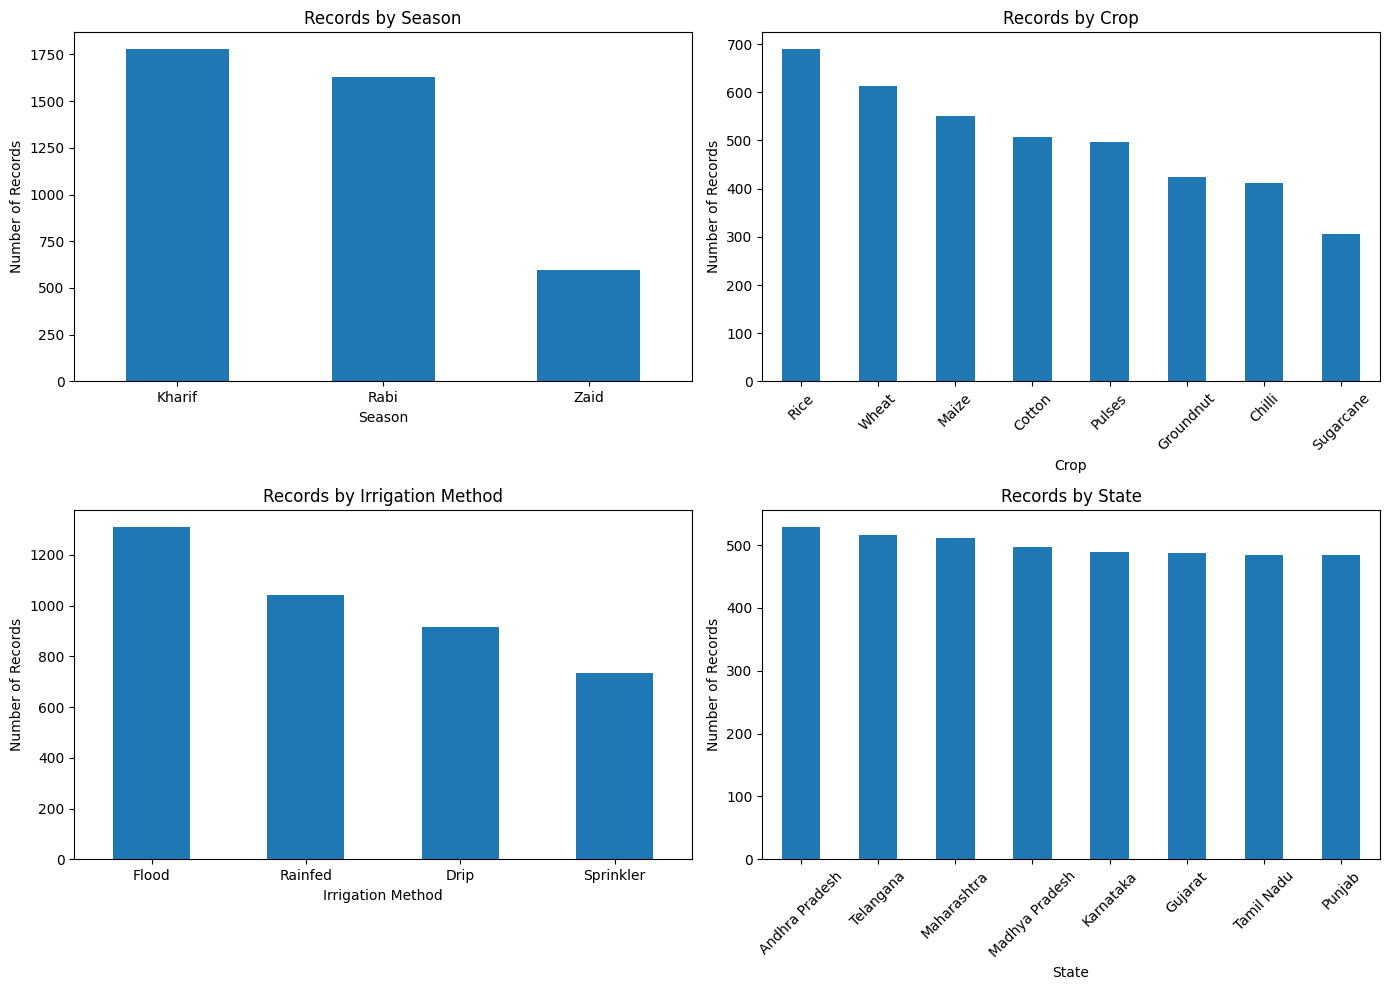

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["Season"].value_counts().reindex(season_order).plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Records by Season")
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Number of Records")
axes[0, 0].tick_params(axis="x", rotation=0)

df["Crop"].value_counts().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Records by Crop")
axes[0, 1].set_xlabel("Crop")
axes[0, 1].set_ylabel("Number of Records")
axes[0, 1].tick_params(axis="x", rotation=45)

df["Irrigation_Method"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Records by Irrigation Method")
axes[1, 0].set_xlabel("Irrigation Method")
axes[1, 0].set_ylabel("Number of Records")
axes[1, 0].tick_params(axis="x", rotation=0)

df["State"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Records by State")
axes[1, 1].set_xlabel("State")
axes[1, 1].set_ylabel("Number of Records")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 11. Key Question 1 — How Does Agricultural Performance Vary Across Seasons?

We compare:
- yield,
- production,
- revenue,
- cost,
- profit,
- profitable-farm rate,
- water efficiency.

In [ ]:
season_performance = (
    df.groupby("Season", observed=False)
      .agg(
          Records=("Farm_ID", "count"),
          Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
          Median_Yield_t_ha=("Yield_Tonnes_Ha", "median"),
          Avg_Production_t=("Production_Tonnes", "mean"),
          Avg_Revenue_INR=("Revenue_INR", "mean"),
          Avg_Cost_INR=("Total_Cost_INR", "mean"),
          Avg_Profit_INR=("Profit_INR", "mean"),
          Median_Profit_INR=("Profit_INR", "median"),
          Profitable_Farm_Rate=("Is_Profitable", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .reindex(season_order)
)

season_performance["Profitable_Farm_Rate_pct"] = (
    season_performance["Profitable_Farm_Rate"] * 100
)

display(season_performance.round(2))

,Records,Avg_Yield_t_ha,Median_Yield_t_ha,Avg_Production_t,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Median_Profit_INR,Profitable_Farm_Rate,Avg_Water_Efficiency,Profitable_Farm_Rate_pct
Season,,,,,,,,,,,
Kharif,1779,5.63,1.94,46.31,"710,719.06","531,804.41","178,914.65","38,808.00",0.58,5.89,57.79
Rabi,1627,5.09,1.66,41.49,"601,526.05","513,836.58","87,689.47","-3,187.00",0.49,5.19,48.86
Zaid,594,4.63,1.45,38.89,"519,171.90","543,976.73","-24,804.82","-62,144.00",0.36,4.41,35.52


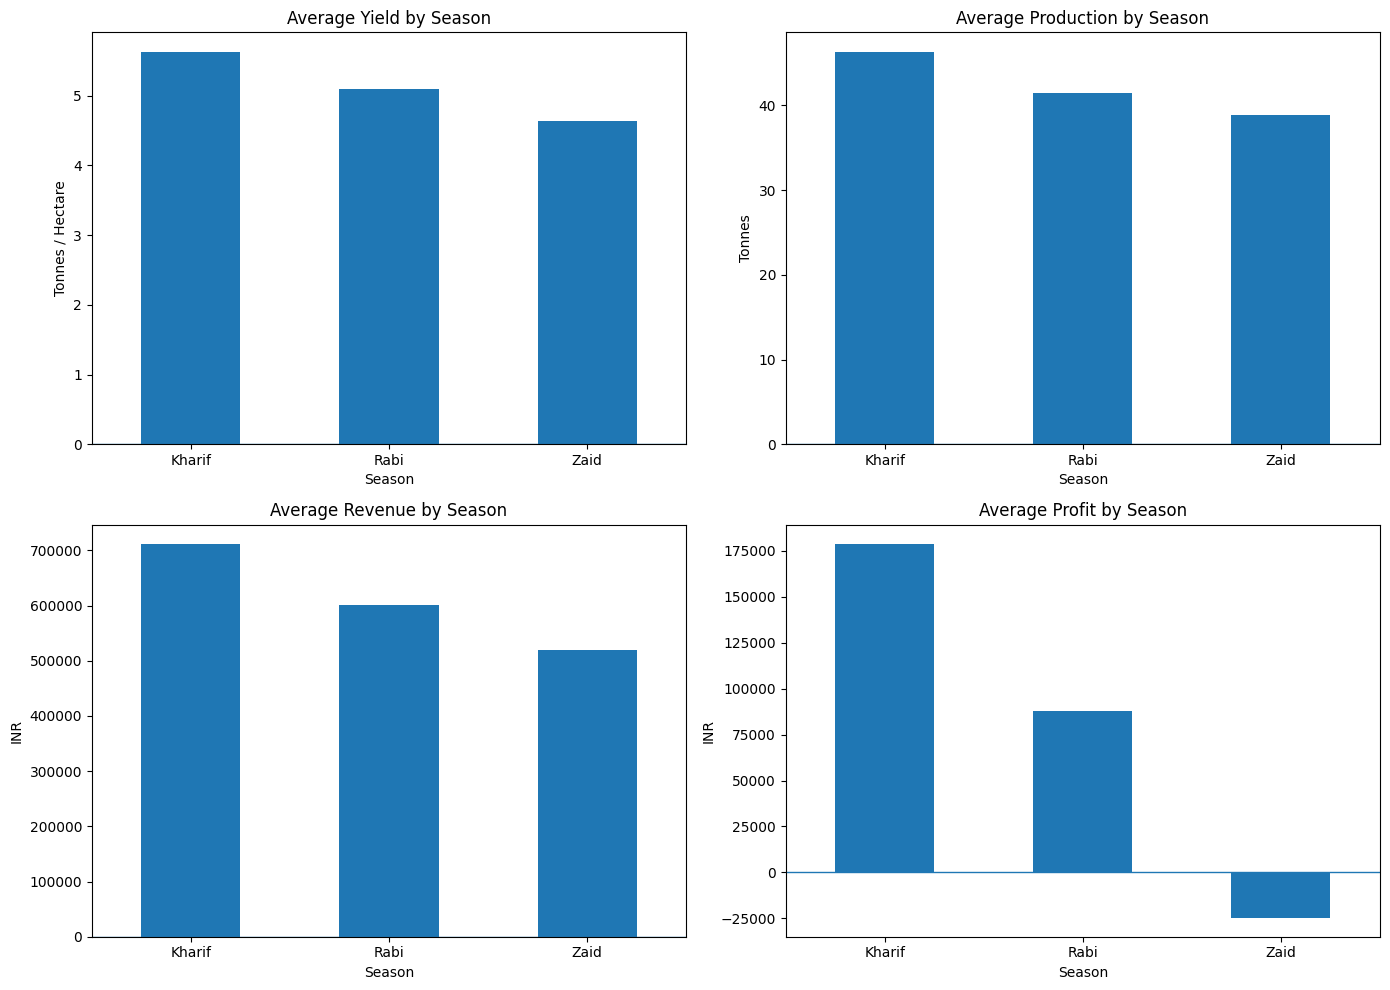

In [ ]:
metrics = [
    ("Yield_Tonnes_Ha", "Average Yield by Season", "Tonnes / Hectare"),
    ("Production_Tonnes", "Average Production by Season", "Tonnes"),
    ("Revenue_INR", "Average Revenue by Season", "INR"),
    ("Profit_INR", "Average Profit by Season", "INR")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, title, ylabel) in zip(axes.flat, metrics):
    values = df.groupby("Season", observed=False)[col].mean().reindex(season_order)
    values.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Season")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

### Dataset-specific observation
With this dataset, **Kharif** has the strongest average yield and profit, **Rabi** is intermediate, and **Zaid** has the lowest average yield and negative average profit.  
This pattern should be interpreted together with environmental conditions, crop mix, irrigation method and resource use rather than as a season-only causal effect.

# 12. Key Question 2 — Seasonal Environmental Patterns

We examine:
- rainfall,
- average temperature,
- humidity,
- sunlight,
- soil moisture,
- disease/pest risk.

In [ ]:
environment_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct", "Disease_Pest_Risk_pct"
]

season_environment = (
    df.groupby("Season", observed=False)[environment_cols]
      .mean()
      .reindex(season_order)
)

display(season_environment.round(2))

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20,54.47
Rabi,435.95,23.49,57.89,7.59,24.05,40.48
Zaid,299.16,31.04,52.01,8.18,19.18,38.22


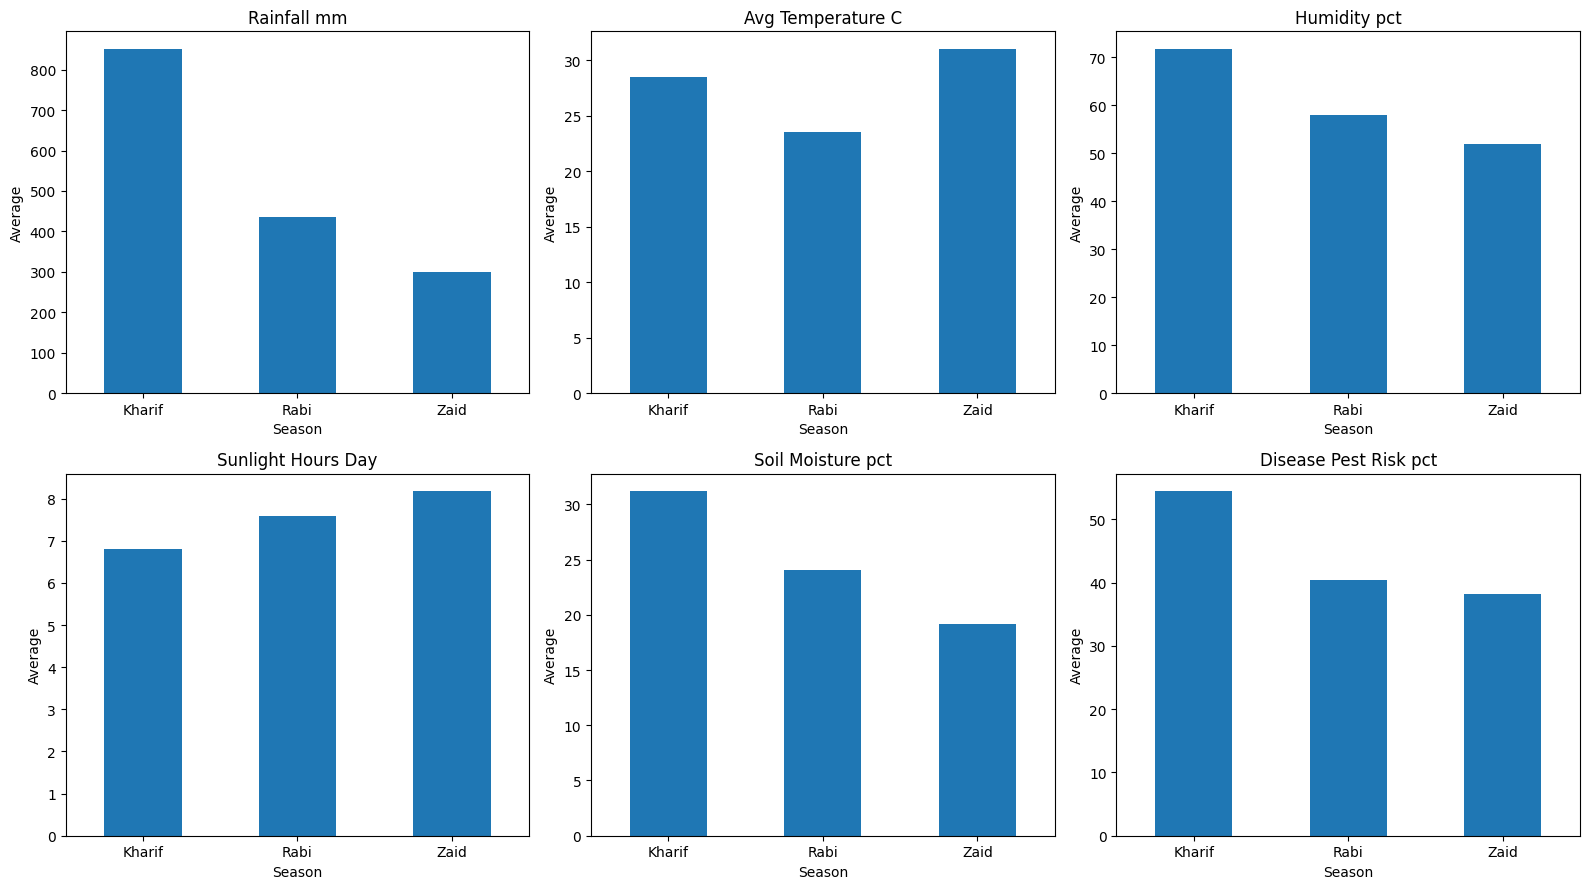

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, environment_cols):
    values = df.groupby("Season", observed=False)[col].mean().reindex(season_order)
    values.plot(kind="bar", ax=ax)
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Season")
    ax.set_ylabel("Average")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Dataset-specific observation
The seasonal environment is clearly differentiated:
- **Kharif** has the highest rainfall, humidity and soil moisture, along with the highest disease/pest risk.
- **Rabi** has moderate rainfall and cooler temperatures.
- **Zaid** is the hottest and driest season, with the highest average sunlight and the lowest soil moisture.

These differences provide a logical context for later yield, water-efficiency and profitability comparisons.

# 13. Key Question 3 — Does Resource Usage Vary Across Seasons?

Resource variables:
- fertilizer,
- pesticide,
- water use,
- N/P/K nutrients,
- irrigation method.

In [ ]:
resource_cols = [
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3",
    "Water_Used_per_Ha", "Water_Efficiency_t_per_1000m3"
]

season_resources = (
    df.groupby("Season", observed=False)[resource_cols]
      .mean()
      .reindex(season_order)
)

display(season_resources.round(2))

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Used_per_Ha,Water_Efficiency_t_per_1000m3
Season,,,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20",758.17,5.89
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99",763.36,5.19
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89",792.58,4.41


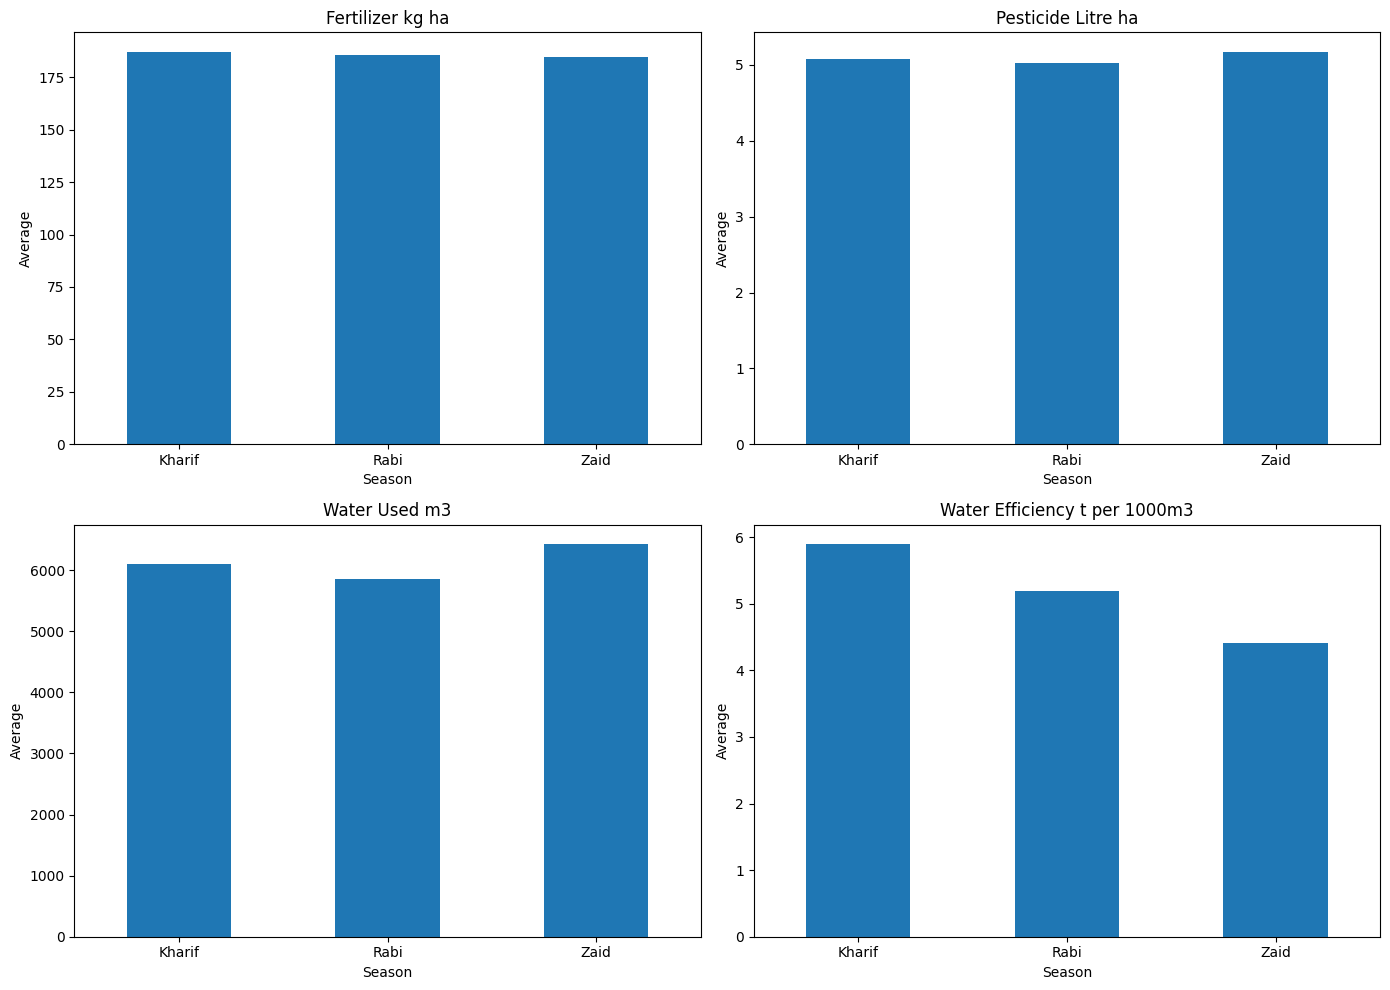

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(
    axes.flat,
    ["Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3", "Water_Efficiency_t_per_1000m3"]
):
    values = df.groupby("Season", observed=False)[col].mean().reindex(season_order)
    values.plot(kind="bar", ax=ax)
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Season")
    ax.set_ylabel("Average")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


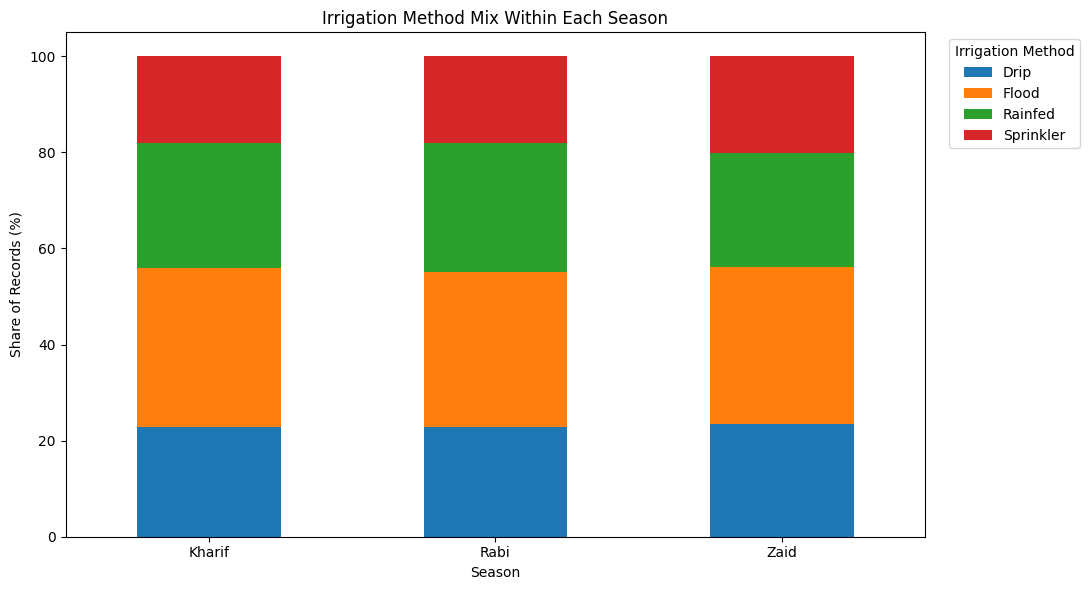

In [ ]:
irrigation_mix = pd.crosstab(
    df["Season"],
    df["Irrigation_Method"],
    normalize="index"
) * 100

irrigation_mix = irrigation_mix.reindex(season_order)
display(irrigation_mix.round(2))

irrigation_mix.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.title("Irrigation Method Mix Within Each Season")
plt.xlabel("Season")
plt.ylabel("Share of Records (%)")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 14. Key Question 4 — Economic Outcomes Across Seasons

This section compares:
- average revenue,
- average cost,
- average profit,
- median profit,
- profit per hectare,
- profitability rate,
- market price.

In [ ]:
economic_cols = [
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR",
    "Profit_INR", "Revenue_per_Ha", "Cost_per_Ha", "Profit_per_Ha"
]

season_economics = (
    df.groupby("Season", observed=False)[economic_cols]
      .mean()
      .reindex(season_order)
)

season_economics["Median_Profit_INR"] = (
    df.groupby("Season", observed=False)["Profit_INR"]
      .median()
      .reindex(season_order)
)

season_economics["Profitable_Farm_pct"] = (
    df.groupby("Season", observed=False)["Is_Profitable"]
      .mean()
      .reindex(season_order) * 100
)

display(season_economics.round(2))

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Revenue_per_Ha,Cost_per_Ha,Profit_per_Ha,Median_Profit_INR,Profitable_Farm_pct
Season,,,,,,,,,
Kharif,"44,850.91","531,804.41","710,719.06","178,914.65","88,782.79","66,900.98","21,881.81","38,808.00",57.79
Rabi,"44,747.97","513,836.58","601,526.05","87,689.47","76,656.92","66,295.24","10,361.68","-3,187.00",48.86
Zaid,"44,212.03","543,976.73","519,171.90","-24,804.82","64,301.42","66,937.94","-2,636.52","-62,144.00",35.52


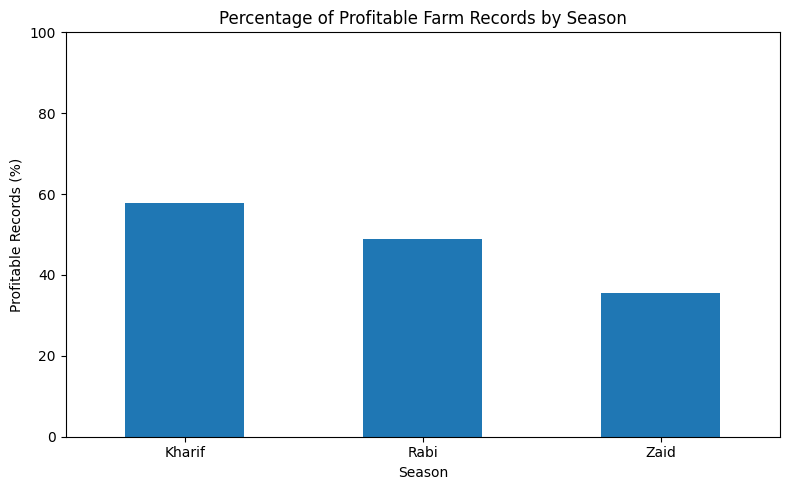

In [ ]:
profitability_rate = (
    df.groupby("Season", observed=False)["Is_Profitable"]
      .mean()
      .reindex(season_order) * 100
)

profitability_rate.plot(kind="bar", figsize=(8, 5))
plt.title("Percentage of Profitable Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Profitable Records (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 15. Key Question 5 — Which Crops Perform Best in Each Season?

Because crops can have very different natural yield scales, we examine both:
- yield,
- profit.

This prevents a high-yield crop from automatically being interpreted as the most profitable crop.

In [ ]:
crop_season = (
    df.groupby(["Crop", "Season"], observed=False)
      .agg(
          Records=("Farm_ID", "count"),
          Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
          Avg_Production_t=("Production_Tonnes", "mean"),
          Avg_Profit_INR=("Profit_INR", "mean"),
          Profitable_Rate_pct=("Is_Profitable", lambda s: s.mean() * 100),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean")
      )
      .reset_index()
)

display(crop_season.round(2))

,Crop,Season,Records,Avg_Yield_t_ha,Avg_Production_t,Avg_Profit_INR,Profitable_Rate_pct,Avg_Water_Efficiency,Avg_Disease_Risk_pct
0,Chilli,Kharif,185,1.73,14.46,"954,380.42",85.41,3.26,52.81
1,Chilli,Rabi,163,1.46,10.97,"638,572.50",78.53,2.89,40.59
2,Chilli,Zaid,64,1.18,9.98,"448,659.09",81.25,2.20,40.50
3,Cotton,Kharif,215,1.37,10.41,"216,999.55",72.09,2.13,54.24
4,Cotton,Rabi,201,1.19,9.44,"107,343.59",66.17,1.94,41.54
5,Cotton,Zaid,92,0.94,6.93,"-53,925.34",47.83,1.49,36.34
6,Groundnut,Kharif,193,1.48,10.49,"108,265.44",66.84,3.58,54.28
7,Groundnut,Rabi,177,1.23,9.06,"10,416.54",56.50,2.90,39.76
8,Groundnut,Zaid,54,1.04,8.62,"-68,872.50",40.74,2.47,39.13
9,Maize,Kharif,234,2.97,23.35,"-39,332.67",46.58,6.05,54.82


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.94
Groundnut,1.48,1.23,1.04
Maize,2.97,2.62,2.28
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.95,38.42
Wheat,2.25,2.06,1.75


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.42","638,572.50","448,659.09"
Cotton,"216,999.55","107,343.59","-53,925.34"
Groundnut,"108,265.44","10,416.54","-68,872.50"
Maize,"-39,332.67","-89,133.40","-194,049.17"
Pulses,"43,338.90","-14,309.14","-139,227.81"
Rice,"-64,903.40","-98,427.87","-227,239.34"
Sugarcane,"1,000,790.81","731,612.86","583,635.80"
Wheat,"-105,871.87","-119,954.57","-193,208.95"


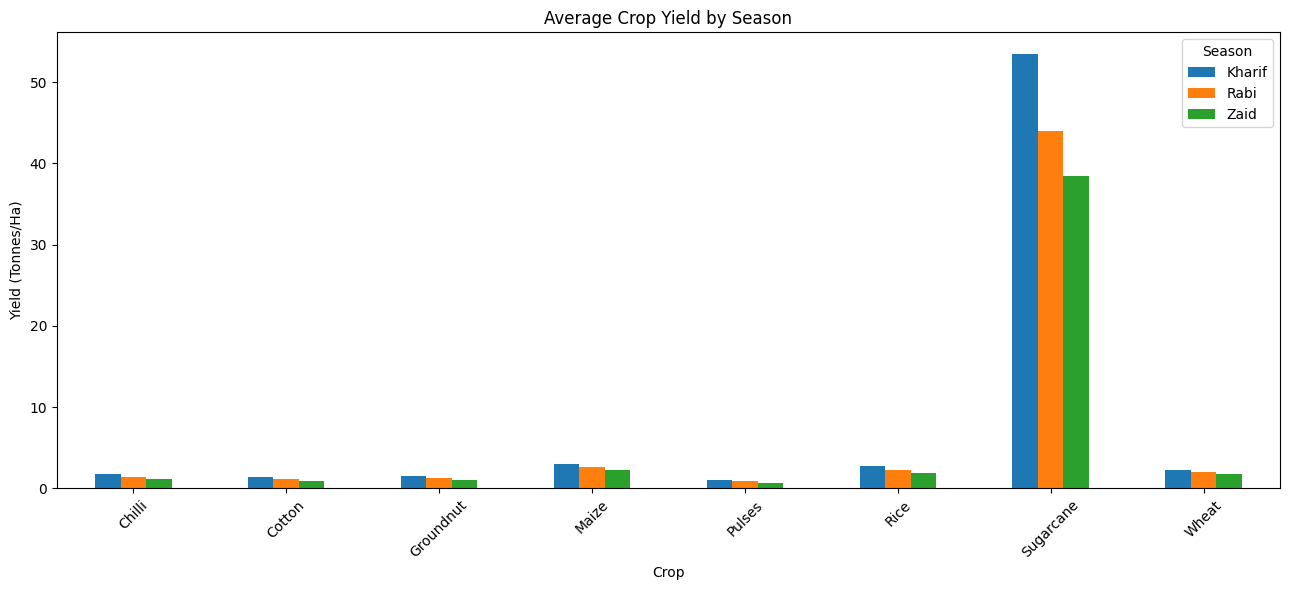

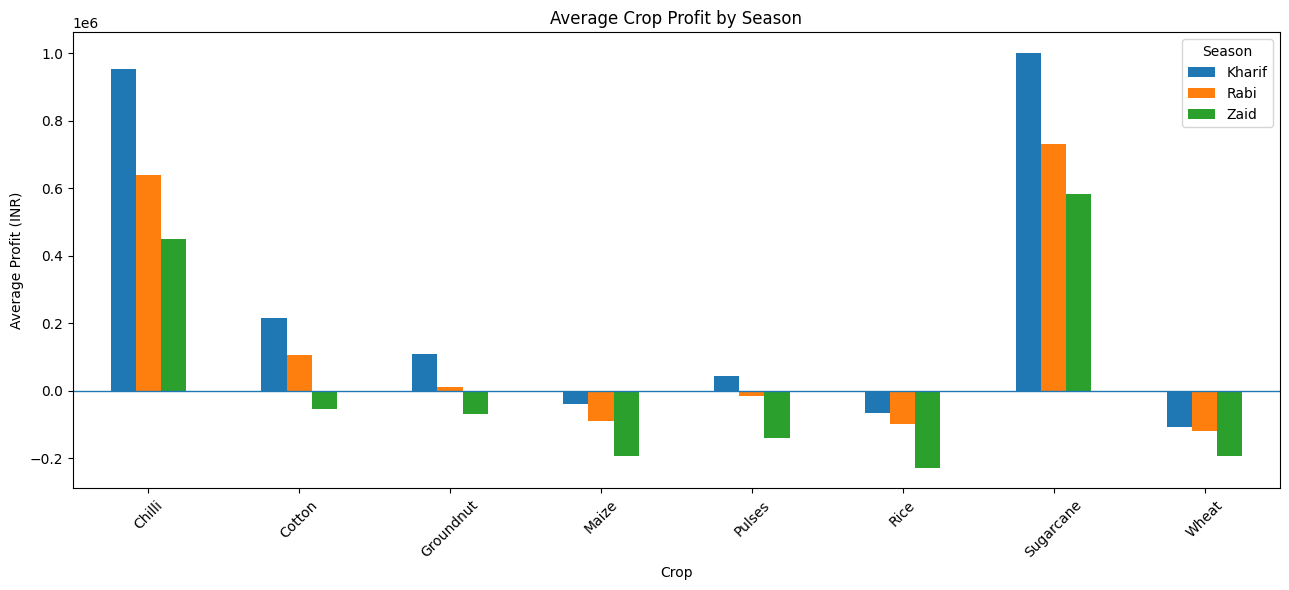

In [ ]:
yield_pivot = df.pivot_table(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean",
    observed=False
).reindex(columns=season_order)

profit_pivot = df.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean",
    observed=False
).reindex(columns=season_order)

display(yield_pivot.round(2))
display(profit_pivot.round(2))

yield_pivot.plot(kind="bar", figsize=(13, 6))
plt.title("Average Crop Yield by Season")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

profit_pivot.plot(kind="bar", figsize=(13, 6))
plt.title("Average Crop Profit by Season")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

# 16. Key Question 6 — Irrigation Method Performance Within Seasons

We compare each irrigation method using:
- yield,
- profit,
- water efficiency,
- water use.

In [ ]:
irrigation_performance = (
    df.groupby(["Season", "Irrigation_Method"], observed=False)
      .agg(
          Records=("Farm_ID", "count"),
          Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit_INR=("Profit_INR", "mean"),
          Avg_Water_Used_m3=("Water_Used_m3", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Profitable_Rate_pct=("Is_Profitable", lambda s: s.mean() * 100)
      )
      .reset_index()
)

display(irrigation_performance.round(2))

,Season,Irrigation_Method,Records,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Profitable_Rate_pct
0,Kharif,Drip,405,7.26,"317,222.07","5,953.37",6.80,65.93
1,Kharif,Flood,590,4.98,"133,373.83","8,229.27",3.64,53.73
2,Kharif,Rainfed,463,5.70,"158,974.13","3,687.52",8.85,55.72
3,Kharif,Sprinkler,321,4.67,"116,880.49","5,863.27",4.62,57.94
4,Rabi,Drip,370,6.35,"187,843.22","5,911.41",6.05,60.54
5,Rabi,Flood,526,5.06,"58,824.80","7,766.83",3.48,44.87
6,Rabi,Rainfed,438,3.93,"45,232.48","3,298.29",6.87,44.52
7,Rabi,Sprinkler,293,5.30,"76,502.07","6,129.09",4.64,47.78
8,Zaid,Drip,140,5.85,"21,291.84","5,837.99",5.30,40.00
9,Zaid,Flood,194,3.97,"-69,786.78","8,113.69",2.73,33.51


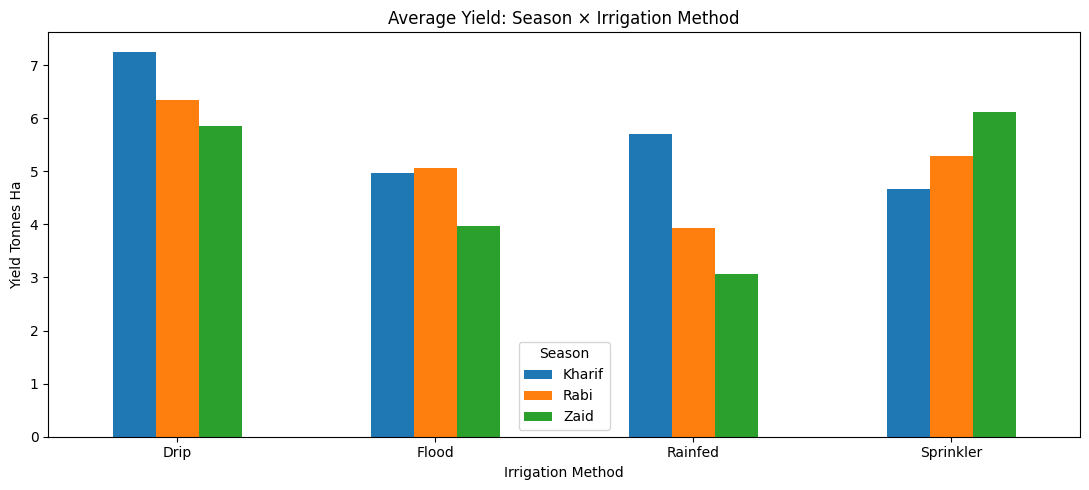

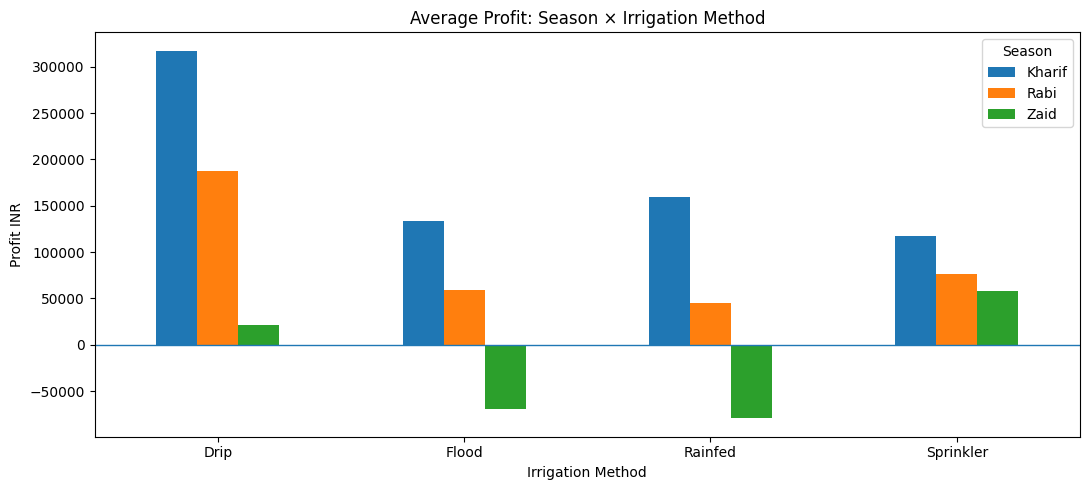

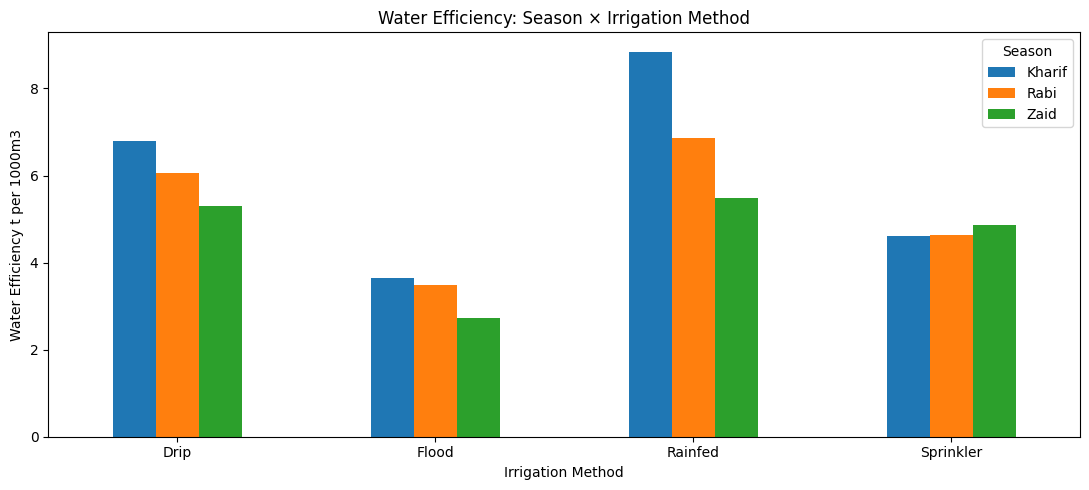

In [ ]:
for metric, title in [
    ("Yield_Tonnes_Ha", "Average Yield: Season × Irrigation Method"),
    ("Profit_INR", "Average Profit: Season × Irrigation Method"),
    ("Water_Efficiency_t_per_1000m3", "Water Efficiency: Season × Irrigation Method")
]:
    pivot = df.pivot_table(
        index="Irrigation_Method",
        columns="Season",
        values=metric,
        aggfunc="mean",
        observed=False
    ).reindex(columns=season_order)

    pivot.plot(kind="bar", figsize=(11, 5))
    plt.title(title)
    plt.xlabel("Irrigation Method")
    plt.ylabel(metric.replace("_", " "))
    plt.xticks(rotation=0)
    plt.legend(title="Season")
    if metric == "Profit_INR":
        plt.axhline(0, linewidth=1)
    plt.tight_layout()
    plt.show()

### Dataset-specific observation
Within this dataset, **Drip irrigation** frequently shows strong yield and profit performance, while **Rainfed** records can show high water-efficiency values because they use less recorded irrigation water.  
These are associations in the dataset, not proof that irrigation method alone caused the result.

# 17. Key Question 7 — Are Seasonal Patterns Consistent Across States?

We compare average yield and profit by `State × Season`.

In [ ]:
state_yield = df.pivot_table(
    index="State",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean",
    observed=False
).reindex(columns=season_order)

state_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean",
    observed=False
).reindex(columns=season_order)

print("Average Yield by State and Season")
display(state_yield.round(2))

print("Average Profit by State and Season")
display(state_profit.round(2))

Average Yield by State and Season


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.70,4.05
Karnataka,6.45,4.73,6.62
Madhya Pradesh,5.99,3.75,5.46
Maharashtra,5.43,5.50,2.26
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.49,4.10
Telangana,5.55,4.82,4.24


Average Profit by State and Season


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,"169,315.52","26,315.71","-84,084.87"
Gujarat,"217,051.33","82,846.20","-106,929.61"
Karnataka,"201,226.21","70,952.61","23,310.91"
Madhya Pradesh,"134,242.40","61,576.26",209.70
Maharashtra,"168,801.05","159,581.50","-40,597.60"
Punjab,"133,779.10","169,294.52","62,109.69"
Tamil Nadu,"211,303.96","70,456.86","-15,175.20"
Telangana,"199,668.38","62,824.60","-34,620.78"


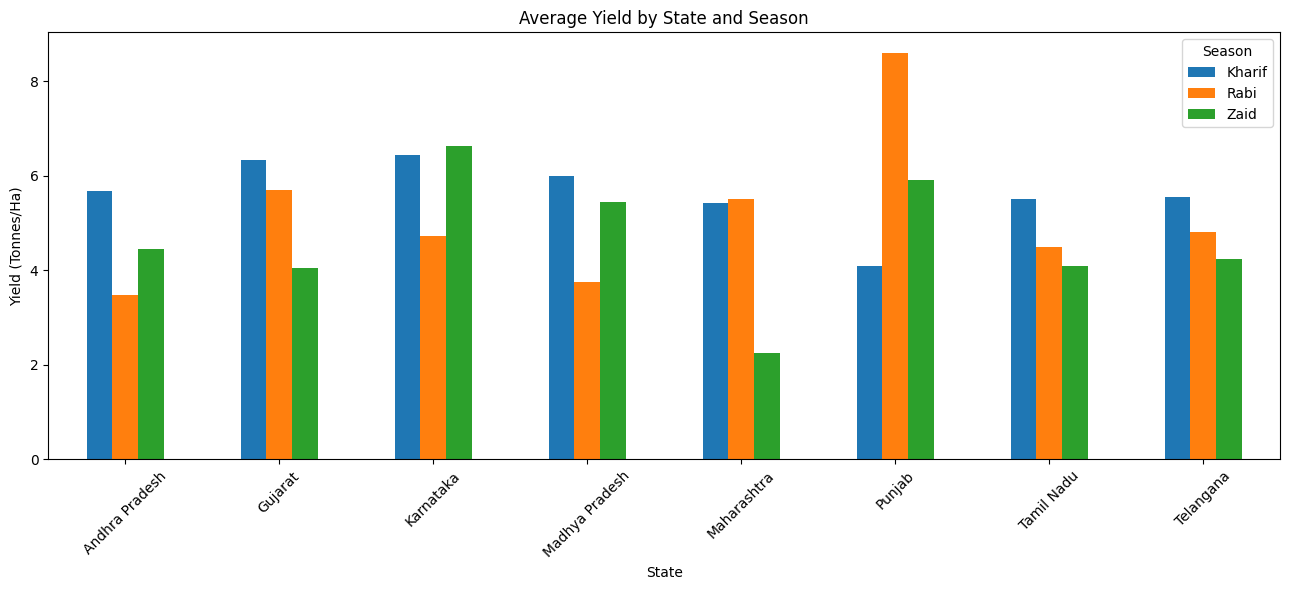

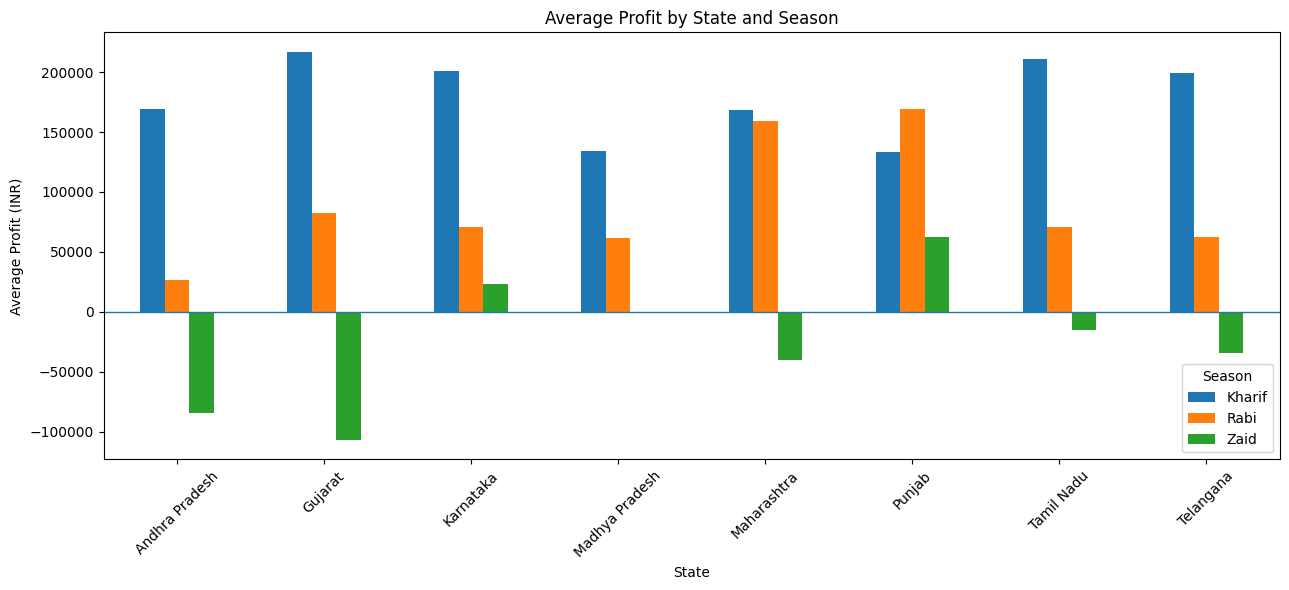

In [ ]:
state_yield.plot(kind="bar", figsize=(13, 6))
plt.title("Average Yield by State and Season")
plt.xlabel("State")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

state_profit.plot(kind="bar", figsize=(13, 6))
plt.title("Average Profit by State and Season")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

# 18. Key Question 8 — Relationships Between Conditions and Outcomes

Because many variables are skewed and contain outliers, **Spearman rank correlation** is used for the main relationship analysis.

We focus on:
- Yield
- Profit
- Water efficiency

In [ ]:
relationship_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score",
    "Yield_Tonnes_Ha", "Production_Tonnes", "Market_Price_INR_Tonne",
    "Total_Cost_INR", "Revenue_INR", "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]

spearman_corr = df[relationship_cols].corr(method="spearman")

print("Strongest associations with Yield:")
display(
    spearman_corr["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=np.abs, ascending=False)
    .head(12)
    .to_frame("Spearman_rho")
)

print("\nStrongest associations with Profit:")
display(
    spearman_corr["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(key=np.abs, ascending=False)
    .head(12)
    .to_frame("Spearman_rho")
)

Strongest associations with Yield:


,Spearman_rho
Production_Tonnes,0.75
Water_Efficiency_t_per_1000m3,0.74
Market_Price_INR_Tonne,-0.58
Profit_INR,0.49
Revenue_INR,0.41
Water_Used_m3,0.26
Rainfall_mm,0.13
Soil_Moisture_pct,0.10
Nitrogen_kg_ha,0.08
Humidity_pct,0.08



Strongest associations with Profit:


,Spearman_rho
Revenue_INR,0.65
Water_Efficiency_t_per_1000m3,0.53
Yield_Tonnes_Ha,0.49
Production_Tonnes,0.40
Market_Price_INR_Tonne,0.20
Rainfall_mm,0.14
Soil_Moisture_pct,0.11
Fertilizer_kg_ha,-0.10
Disease_Pest_Risk_pct,0.10
Humidity_pct,0.09


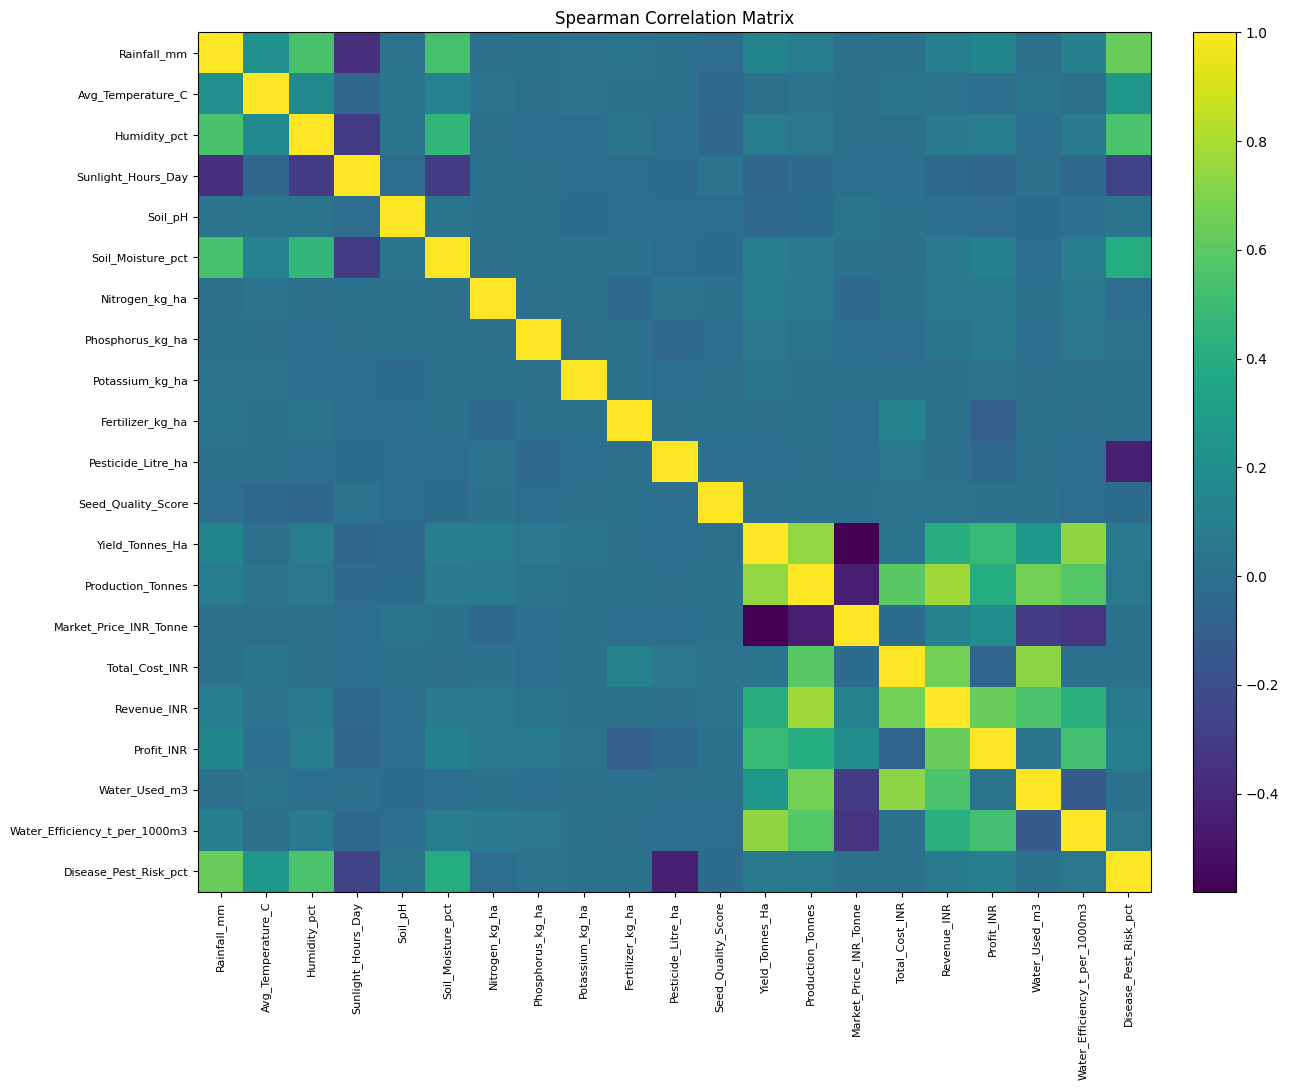

In [ ]:
fig, ax = plt.subplots(figsize=(13, 11))
matrix = ax.imshow(spearman_corr.values, aspect="auto")
ax.set_xticks(range(len(relationship_cols)))
ax.set_yticks(range(len(relationship_cols)))
ax.set_xticklabels(relationship_cols, rotation=90, fontsize=8)
ax.set_yticklabels(relationship_cols, fontsize=8)
ax.set_title("Spearman Correlation Matrix")
fig.colorbar(matrix, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 19. Statistical Significance of Seasonal Differences

## Why Kruskal–Wallis?
Agricultural variables such as yield, production, revenue and profit can be highly skewed and contain large outliers.  
Therefore, we use the **Kruskal–Wallis H-test**, a non-parametric alternative to one-way ANOVA.

### Hypotheses
- **H₀:** The distributions are the same across Kharif, Rabi and Zaid.
- **H₁:** At least one season differs.

A p-value below **0.05** is treated as evidence of a statistically significant seasonal difference.

In [ ]:
test_metrics = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct"
]

kruskal_results = []

for metric in test_metrics:
    groups = [
        df.loc[df["Season"] == season, metric].dropna().values
        for season in season_order
    ]
    h_stat, p_value = kruskal(*groups)

    kruskal_results.append({
        "Metric": metric,
        "H_Statistic": h_stat,
        "p_value": p_value,
        "Significant_at_0.05": p_value < 0.05
    })

kruskal_results = pd.DataFrame(kruskal_results)
display(kruskal_results)

,Metric,H_Statistic,p_value,Significant_at_0.05
0,Yield_Tonnes_Ha,70.59,0.00,True
1,Production_Tonnes,26.10,0.00,True
2,Profit_INR,101.93,0.00,True
3,Water_Used_m3,5.97,0.05,False
4,Water_Efficiency_t_per_1000m3,56.81,0.00,True
5,Disease_Pest_Risk_pct,"1,430.91",0.00,True
6,Rainfall_mm,"2,599.88",0.00,True
7,Avg_Temperature_C,"2,385.97",0.00,True
8,Humidity_pct,"1,845.51",0.00,True
9,Soil_Moisture_pct,"1,857.61",0.00,True


## 19.1 Pairwise Seasonal Tests

If the overall Kruskal–Wallis test is significant, pairwise **Mann–Whitney U tests** help identify which season pairs differ.

A **Bonferroni correction** is applied because three pairwise tests are performed for each metric.

In [ ]:
from itertools import combinations

pairs = list(combinations(season_order, 2))
pairwise_results = []

for metric in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3"]:
    for s1, s2 in pairs:
        x = df.loc[df["Season"] == s1, metric].dropna()
        y = df.loc[df["Season"] == s2, metric].dropna()

        u_stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
        adjusted_p = min(p_value * len(pairs), 1.0)

        pairwise_results.append({
            "Metric": metric,
            "Season_1": s1,
            "Season_2": s2,
            "U_Statistic": u_stat,
            "Raw_p": p_value,
            "Bonferroni_Adjusted_p": adjusted_p,
            "Significant_at_0.05": adjusted_p < 0.05
        })

pairwise_results = pd.DataFrame(pairwise_results)
display(pairwise_results)

,Metric,Season_1,Season_2,U_Statistic,Raw_p,Bonferroni_Adjusted_p,Significant_at_0.05
0,Yield_Tonnes_Ha,Kharif,Rabi,"1,593,425.50",0.00,0.00,True
1,Yield_Tonnes_Ha,Kharif,Zaid,"643,655.00",0.00,0.00,True
2,Yield_Tonnes_Ha,Rabi,Zaid,"541,962.00",0.00,0.00,True
3,Profit_INR,Kharif,Rabi,"1,594,632.50",0.00,0.00,True
4,Profit_INR,Kharif,Zaid,"668,508.00",0.00,0.00,True
5,Profit_INR,Rabi,Zaid,"570,725.00",0.00,0.00,True
6,Water_Efficiency_t_per_1000m3,Kharif,Rabi,"1,559,766.00",0.00,0.00,True
7,Water_Efficiency_t_per_1000m3,Kharif,Zaid,"634,140.50",0.00,0.00,True
8,Water_Efficiency_t_per_1000m3,Rabi,Zaid,"545,246.00",0.00,0.00,True


# 20. Key Question 9 — Unusual or Unexpected Patterns

We use the **IQR rule** to flag potential outliers. Outliers are not automatically errors; in agriculture they may represent:
- genuinely high-performing farms,
- high-value crops,
- unusual weather/resource conditions,
- data-quality issues that require investigation.

In [ ]:
outlier_cols = [
    "Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR", "Profit_INR",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Potential_Outliers": count,
        "Outlier_Percent": count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary.round(2))

,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Potential_Outliers,Outlier_Percent
0,Yield_Tonnes_Ha,1.05,2.84,-1.63,5.52,304,7.60
1,Production_Tonnes,5.02,24.36,-23.98,53.36,333,8.33
2,Revenue_INR,"207,517.25","836,874.75","-736,519.00","1,780,911.00",240,6.00
3,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404,10.10
4,Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276,6.90
5,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322,8.05
6,Disease_Pest_Risk_pct,37.30,54.90,10.90,81.30,10,0.25


In [ ]:
# Inspect the most extreme profit and yield records
print("Top 10 Profit Records")
display(
    df.nlargest(10, "Profit_INR")[
        ["Farm_ID", "State", "Crop", "Season", "Irrigation_Method",
         "Yield_Tonnes_Ha", "Revenue_INR", "Total_Cost_INR", "Profit_INR"]
    ]
)

print("\nBottom 10 Profit Records")
display(
    df.nsmallest(10, "Profit_INR")[
        ["Farm_ID", "State", "Crop", "Season", "Irrigation_Method",
         "Yield_Tonnes_Ha", "Revenue_INR", "Total_Cost_INR", "Profit_INR"]
    ]
)

print("\nTop 10 Yield Records")
display(
    df.nlargest(10, "Yield_Tonnes_Ha")[
        ["Farm_ID", "State", "Crop", "Season", "Irrigation_Method",
         "Yield_Tonnes_Ha", "Production_Tonnes", "Water_Efficiency_t_per_1000m3"]
    ]
)

Top 10 Profit Records


,Farm_ID,State,Crop,Season,Irrigation_Method,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
2236,SF12237,Punjab,Chilli,Kharif,Flood,3.90,5057448,712027,4345421
626,SF10627,Maharashtra,Chilli,Kharif,Flood,2.92,5080900,1059050,4021850
3425,SF13426,Madhya Pradesh,Sugarcane,Kharif,Drip,82.68,4485260,745161,3740099
1690,SF11691,Karnataka,Chilli,Kharif,Drip,3.01,4522464,784135,3738329
247,SF10248,Maharashtra,Chilli,Kharif,Flood,3.09,4825365,1283161,3542204
357,SF10358,Punjab,Sugarcane,Rabi,Sprinkler,84.75,4350998,972119,3378879
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,Drip,95.79,4428460,1097878,3330582
1930,SF11931,Tamil Nadu,Sugarcane,Kharif,Drip,79.25,4108301,875331,3232970
3983,SF13984,Gujarat,Chilli,Kharif,Drip,3.02,4055609,844264,3211345
263,SF10264,Maharashtra,Chilli,Rabi,Sprinkler,2.53,3987664,828217,3159447



Bottom 10 Profit Records


,Farm_ID,State,Crop,Season,Irrigation_Method,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
780,SF10781,Andhra Pradesh,Groundnut,Rabi,Sprinkler,0.30,280139,1299362,-1019223
2210,SF12211,Andhra Pradesh,Wheat,Rabi,Drip,0.30,102497,1097692,-995195
3625,SF13626,Punjab,Maize,Rabi,Flood,0.97,226503,1207553,-981050
2182,SF12183,Andhra Pradesh,Rice,Kharif,Flood,1.01,320865,1297725,-976860
104,SF10105,Gujarat,Wheat,Zaid,Flood,0.30,98792,1063989,-965197
3394,SF13395,Gujarat,Wheat,Kharif,Flood,0.30,99644,1063040,-963396
2730,SF12731,Madhya Pradesh,Rice,Rabi,Sprinkler,0.30,89197,995279,-906082
1311,SF11312,Punjab,Rice,Zaid,Drip,0.45,163084,1065824,-902740
585,SF10586,Telangana,Cotton,Zaid,Sprinkler,0.30,198300,1094030,-895730
3090,SF13091,Karnataka,Maize,Kharif,Drip,0.41,109026,999667,-890641



Top 10 Yield Records


,Farm_ID,State,Crop,Season,Irrigation_Method,Yield_Tonnes_Ha,Production_Tonnes,Water_Efficiency_t_per_1000m3
1715,SF11716,Gujarat,Sugarcane,Kharif,Drip,101.44,641.10,54.42
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,Drip,95.79,"1,424.40",61.16
3525,SF13526,Andhra Pradesh,Sugarcane,Rabi,Drip,93.13,648.18,60.55
1464,SF11465,Gujarat,Sugarcane,Kharif,Drip,91.98,703.65,55.03
3523,SF13524,Karnataka,Sugarcane,Kharif,Flood,91.46,75.00,38.58
2782,SF12783,Gujarat,Sugarcane,Rabi,Flood,91.32,522.35,42.82
644,SF10645,Andhra Pradesh,Sugarcane,Kharif,Drip,89.34,668.26,57.87
2847,SF12848,Telangana,Sugarcane,Kharif,Drip,87.76,672.24,53.67
357,SF10358,Punjab,Sugarcane,Rabi,Sprinkler,84.75,"1,249.21",52.19
1178,SF11179,Karnataka,Sugarcane,Kharif,Drip,83.79,534.58,48.22


# 21. Optional Advanced Analysis — Feature Importance for Yield

This section is included to strengthen the major project.

A Random Forest model is used to explore which variables are most useful for predicting `Yield_Tonnes_Ha`.

### Important
Feature importance shows **predictive usefulness**, not causation.

In [ ]:
model_features = [
    "State", "Crop", "Season", "Irrigation_Method",
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Sunlight_Hours_Day", "Soil_pH",
    "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
    "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Water_Used_m3", "Disease_Pest_Risk_pct"
]

target = "Yield_Tonnes_Ha"

X = df[model_features].copy()
y = df[target].copy()

categorical_features = ["State", "Crop", "Season", "Irrigation_Method"]
numeric_features = [c for c in model_features if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print(f"MAE:  {mae:.3f} tonnes/ha")
print(f"RMSE: {rmse:.3f} tonnes/ha")
print(f"R²:   {r2:.3f}")

MAE:  0.747 tonnes/ha
RMSE: 2.616 tonnes/ha
R²:   0.965


,Importance
Original_Feature,
Crop,0.81
Soil_pH,0.14
Rainfall_mm,0.02
Nitrogen_kg_ha,0.01
Avg_Temperature_C,0.00
Irrigation_Method,0.00
Fertilizer_kg_ha,0.00
Pesticide_Litre_ha,0.00
Sunlight_Hours_Day,0.00


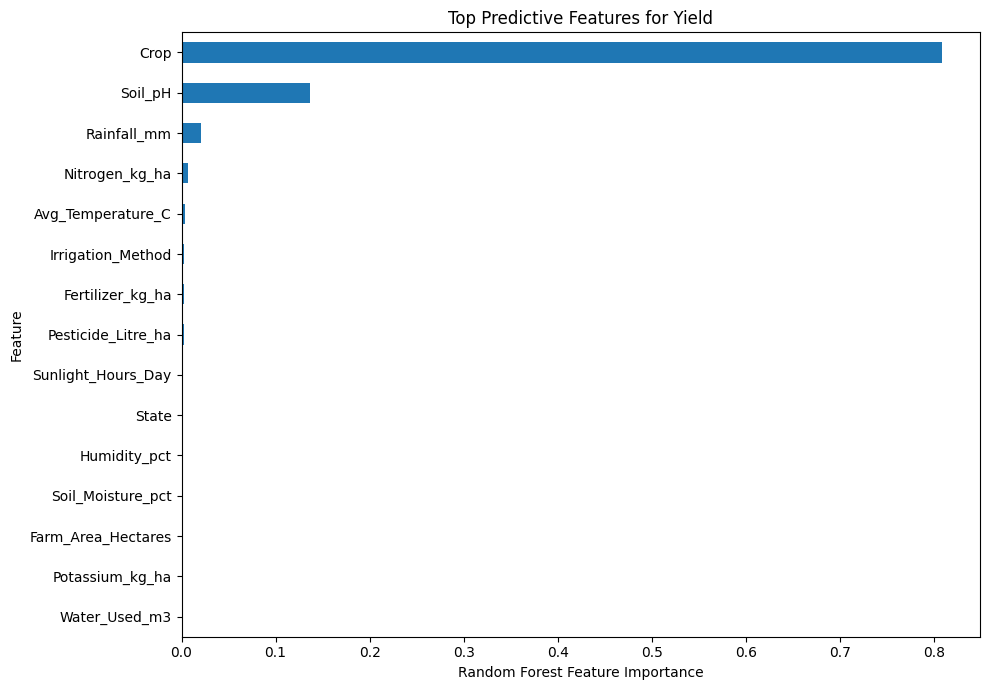

In [ ]:
# Extract and aggregate feature importances back to original variables
encoder = pipeline.named_steps["preprocessor"].named_transformers_["categorical"]
encoded_names = encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = encoded_names + numeric_features

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Encoded_Feature": all_feature_names,
    "Importance": importances
})

def original_feature_name(encoded_feature):
    for cat in categorical_features:
        if encoded_feature.startswith(cat + "_"):
            return cat
    return encoded_feature

importance_df["Original_Feature"] = importance_df["Encoded_Feature"].apply(original_feature_name)

aggregated_importance = (
    importance_df.groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

display(aggregated_importance.head(15))

aggregated_importance.head(15).sort_values("Importance").plot(
    kind="barh", figsize=(10, 7), legend=False
)
plt.title("Top Predictive Features for Yield")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 22. Automatic Summary of Core Findings

This cell generates a concise evidence-based project summary directly from the cleaned dataset.

In [ ]:
season_summary = (
    df.groupby("Season", observed=False)
      .agg(
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Rainfall=("Rainfall_mm", "mean"),
          Avg_Temperature=("Avg_Temperature_C", "mean"),
          Avg_Soil_Moisture=("Soil_Moisture_pct", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
          Profitable_Rate=("Is_Profitable", "mean")
      )
      .reindex(season_order)
)

best_yield_season = season_summary["Avg_Yield"].idxmax()
best_profit_season = season_summary["Avg_Profit"].idxmax()
best_water_eff_season = season_summary["Avg_Water_Efficiency"].idxmax()
highest_risk_season = season_summary["Avg_Disease_Risk"].idxmax()
lowest_profit_season = season_summary["Avg_Profit"].idxmin()

print("CORE FINDINGS")
print("=" * 70)
print(f"1. Highest average yield season: {best_yield_season} "
      f"({season_summary.loc[best_yield_season, 'Avg_Yield']:.2f} t/ha)")
print(f"2. Highest average profit season: {best_profit_season} "
      f"(₹{season_summary.loc[best_profit_season, 'Avg_Profit']:,.0f})")
print(f"3. Lowest average profit season: {lowest_profit_season} "
      f"(₹{season_summary.loc[lowest_profit_season, 'Avg_Profit']:,.0f})")
print(f"4. Highest average water-efficiency season: {best_water_eff_season} "
      f"({season_summary.loc[best_water_eff_season, 'Avg_Water_Efficiency']:.2f} t/1000m³)")
print(f"5. Highest disease/pest-risk season: {highest_risk_season} "
      f"({season_summary.loc[highest_risk_season, 'Avg_Disease_Risk']:.2f}%)")

print("\nSeasonal profitability rates:")
for season in season_order:
    rate = season_summary.loc[season, "Profitable_Rate"] * 100
    print(f"   {season}: {rate:.1f}%")

print("\nSeason-level environmental means:")
display(season_summary.round(2))

CORE FINDINGS
1. Highest average yield season: Kharif (5.63 t/ha)
2. Highest average profit season: Kharif (₹178,915)
3. Lowest average profit season: Zaid (₹-24,805)
4. Highest average water-efficiency season: Kharif (5.89 t/1000m³)
5. Highest disease/pest-risk season: Kharif (54.47%)

Seasonal profitability rates:
   Kharif: 57.8%
   Rabi: 48.9%
   Zaid: 35.5%

Season-level environmental means:


,Avg_Yield,Avg_Profit,Avg_Rainfall,Avg_Temperature,Avg_Soil_Moisture,Avg_Water_Efficiency,Avg_Disease_Risk,Profitable_Rate
Season,,,,,,,,
Kharif,5.63,"178,914.65",852.10,28.45,31.20,5.89,54.47,0.58
Rabi,5.09,"87,689.47",435.95,23.49,24.05,5.19,40.48,0.49
Zaid,4.63,"-24,804.82",299.16,31.04,19.18,4.41,38.22,0.36


# 23. Conclusions

Based on this dataset, the strongest evidence supports the following conclusions:

1. **Agricultural performance differs materially across seasons.**  
   Kharif records show the highest average yield and profit, while Zaid has the weakest profitability.

2. **Seasonal environmental conditions are clearly different.**  
   Kharif is wetter and more humid; Zaid is hotter, sunnier and drier; Rabi lies between them on many measures.

3. **Water efficiency also varies by season.**  
   Kharif has the highest average water efficiency in this dataset, while Zaid has the lowest.

4. **Disease/pest risk is highest in Kharif.**  
   This coincides with higher rainfall and humidity, making pest/disease management particularly important when interpreting Kharif performance.

5. **Crop type matters greatly.**  
   Crop-season comparisons show that crops differ strongly in yield scale and profitability. Therefore, season-level averages should never be interpreted without considering crop mix.

6. **Irrigation method is associated with meaningful differences in yield, profit and water efficiency.**  
   Drip irrigation often performs strongly on yield/profit in this dataset, while rainfed records can appear highly water-efficient due to low recorded irrigation water use.

7. **Seasonal differences are statistically detectable for several core performance and environmental variables.**  
   The Kruskal–Wallis section formally tests these differences.

8. **Extreme values require interpretation rather than automatic deletion.**  
   Some high yields and profits may reflect particular crop types or farm conditions instead of data errors.

> These conclusions are evidence from the provided dataset. They describe associations and observed differences, not guaranteed causal relationships.

# 24. Data-Driven Recommendations

## For seasonal agricultural planning
1. **Use season-specific planning instead of one common strategy.**  
   Environmental and profitability patterns differ substantially among Kharif, Rabi and Zaid.

2. **Strengthen disease/pest monitoring during Kharif.**  
   The dataset shows the highest average disease/pest risk during Kharif.

3. **Investigate Zaid profitability in greater detail.**  
   Zaid shows the lowest average profit and the lowest profitable-record rate, so crop choice, cost structure, irrigation and market price should be examined together.

4. **Use crop-specific benchmarks.**  
   Yield scales differ greatly across crops; comparing all crops with one common yield threshold can be misleading.

5. **Evaluate irrigation strategy using both output and efficiency.**  
   A method that produces high yield is not necessarily the most water-efficient or profitable.

6. **Use state- and crop-level seasonal dashboards.**  
   Overall seasonal averages can hide regional or crop-specific variation.

7. **Investigate extreme values before removing them.**  
   Outlier farms may contain valuable information about high-performance practices or risky cost structures.

8. **Track profitability, not only production.**  
   High production can still produce weak profit if cost is high or market price is low.

# 25. Expected Outcomes Checklist

This notebook addresses the expected outcomes from the project brief:

- ✅ Understand seasonal agricultural data  
- ✅ Perform data cleaning and preparation  
- ✅ Identify important seasonal patterns  
- ✅ Compare agricultural performance across seasons  
- ✅ Discover relationships and variation  
- ✅ Apply suitable statistical techniques  
- ✅ Apply suitable visualization techniques  
- ✅ Interpret findings using dataset evidence  
- ✅ Identify significant/unusual observations  
- ✅ Develop evidence-based insights  
- ✅ Provide recommendations  
- ✅ Document the complete analysis in a Jupyter/Colab notebook

# 26. Export Cleaned Data and Summary Tables

Run this cell after completing the notebook if you want CSV files for Power BI, Excel or project submission.

In [ ]:
OUTPUT_DIR = "/content/agriculture_project_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(f"{OUTPUT_DIR}/seasonal_agriculture_cleaned.csv", index=False)
season_performance.to_csv(f"{OUTPUT_DIR}/season_performance_summary.csv")
season_environment.to_csv(f"{OUTPUT_DIR}/season_environment_summary.csv")
crop_season.to_csv(f"{OUTPUT_DIR}/crop_season_summary.csv", index=False)
irrigation_performance.to_csv(f"{OUTPUT_DIR}/irrigation_performance_summary.csv", index=False)
kruskal_results.to_csv(f"{OUTPUT_DIR}/seasonal_statistical_tests.csv", index=False)

print("Files exported to:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Files exported to: /content/agriculture_project_outputs
['season_performance_summary.csv', 'seasonal_agriculture_cleaned.csv', 'irrigation_performance_summary.csv', 'seasonal_statistical_tests.csv', 'season_environment_summary.csv', 'crop_season_summary.csv']


# 27. Final Project Note

When presenting this project, focus on the **story**:

**Seasonal conditions → resource use → crop performance → economic outcome → planning recommendations**

Avoid claiming that a correlation or group difference proves causation.  
The strongest presentation combines:
- descriptive evidence,
- visual evidence,
- statistical evidence,
- practical interpretation.

### Suggested final presentation headline
> **Season strongly separates environmental conditions and is associated with clear differences in yield, water efficiency and profitability, but crop mix, irrigation strategy and regional context must be considered before making agricultural decisions.**